In [3]:
# 自动重新加载所有模块
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
from typing import Union, List, Tuple
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from lurking_sextet.evaluation.f1_score_stock import *

In [6]:
# 这是一个随便写的测试的因子计算代码。
def factor_test(df_tick:pd.DataFrame, TI:int=30):  
    def weighted_sum(window):
        # 创建权重序列，从1递增到1/T
        weights = np.linspace(1, TI, TI)
        # 计算加权和
        return np.nansum(window * weights)/(weights.sum())
    ask_quant = df_tick[['ask_volume'+str(i) for i in range(1,9)]].mean(axis=1).fillna(0).rolling(TI).apply(weighted_sum, raw=True)
    # print(ask_quant.describe())
    bid_quant = df_tick[['bid_volume'+str(i) for i in range(1,9)]].mean(axis=1).fillna(0).rolling(TI).apply(weighted_sum, raw=True)
    # print(bid_quant.describe())
    f = (ask_quant-bid_quant)/(ask_quant+bid_quant+1e-5)
    f = (f - f.mean())/(f.std() + 1e-5)
    return f.rolling(TI).mean().astype(float)

In [8]:
# 随便取一只股票数据。
# df_am = fetch_tick_data('002050', '2024-12-02','1sTick')
df_am = pd.read_parquet('../lurking_sextet/datasets/f1_score_data.parquet')
df_am.head()

,begin_inv,end_inv,clock,clock_int,symbol,current,open,high,low,tot_volume,...,ask_price9,ask_volume9,bid_price9,bid_volume9,ask_price10,ask_volume10,bid_price10,bid_volume10,ts,AbnormalCode
0,93000000,93001000,2024-12-02 09:30:00.000,93000000,002050,23.47,23.47,23.47,23.47,890500.0,...,23.56,2000.0,23.36,1700.0,23.57,1600.0,23.35,1300.0,1733103000154000000,0
1,93001000,93002000,2024-12-02 09:30:01.010,93001010,002050,23.49,23.47,23.54,23.46,1335500.0,...,23.59,13000.0,23.39,6000.0,23.60,15300.0,23.37,1200.0,1733103008304000000,0
2,93002000,93003000,2024-12-02 09:30:02.010,93002010,002050,23.50,23.47,23.55,23.46,1470500.0,...,23.62,10400.0,23.42,5900.0,23.63,5400.0,23.41,200.0,1733103011640000000,0
3,93003000,93004000,2024-12-02 09:30:03.010,93003010,002050,23.48,23.47,23.55,23.46,1574600.0,...,23.59,14600.0,23.40,26100.0,23.60,15900.0,23.39,6000.0,1733103013918000000,0
4,93004000,93005000,2024-12-02 09:30:04.010,93004010,002050,23.50,23.47,23.55,23.46,1760600.0,...,23.61,800.0,23.42,6300.0,23.62,10400.0,23.41,5000.0,1733103015937000000,0


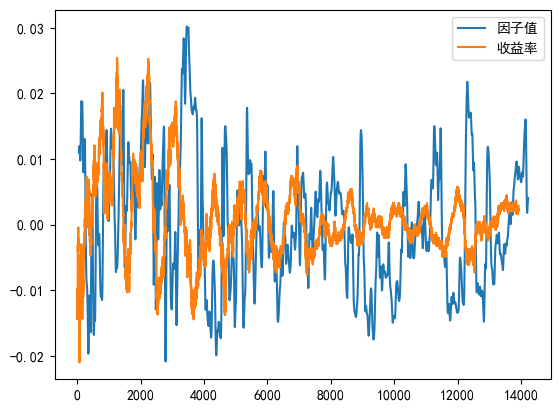

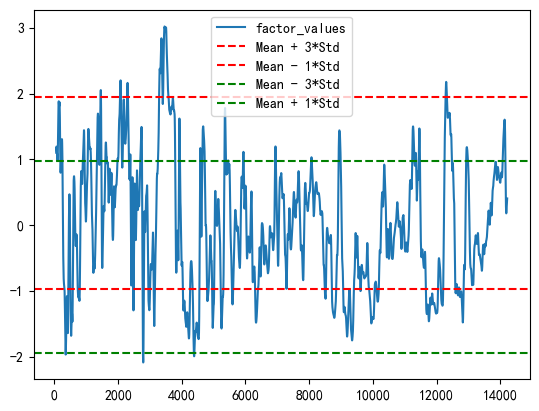

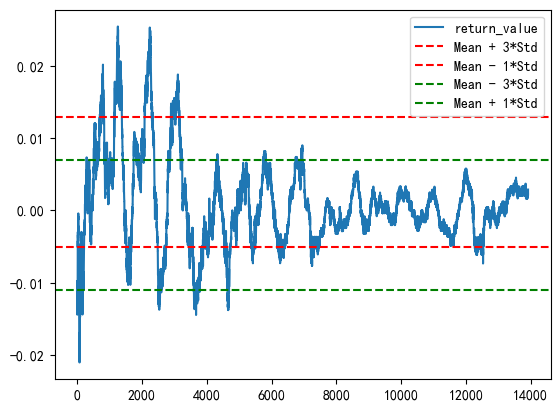

sum_buy_tp: 645
sum_sell_tp: 34
sum_buy_fp: 1433
sum_sell_fp: 1178
sum_buy_fn: 1149
sum_sell_fn: 2358
0.20638297872340425
0.16220735785953178
0.18164794007490634


In [ ]:
#计算因子数据Series
fv = factor_test(df_am)

cur = df_am['current']
# 计算收益率Sereis
rv = ((cur.shift(-300)-cur)/(cur)).rename('rv')
mask = cur < 1e-4
rv = rv.mask(mask, 0)

# 画图大致可视化一下。
plt.plot(fv/100, label = '因子值')
plt.plot(rv, label = '收益率')
plt.legend()
plt.show()

fv_m, rv_m, fv_std, rv_std = fv.mean(), rv.mean(), fv.std(), rv.std()

factor_buy_hold_interval = (fv_m + 2*fv_std, fv_m - 1*fv_std)
factor_sell_hold_interval = (fv_m - 2*fv_std, fv_m + 1*fv_std)
return_buy_hold_interval = (rv_m + 2*rv_std, rv_m - 1*rv_std)
return_sell_hold_interval = (rv_m - 2*rv_std, rv_m + 1*rv_std)

plt.plot(fv, label='factor_values')
plt.axhline(factor_buy_hold_interval[0], color='red', linestyle='--', label='Mean + 2*Std')
plt.axhline(factor_buy_hold_interval[1], color='red', linestyle='--', label='Mean - 1*Std')
plt.axhline(factor_sell_hold_interval[0], color='green', linestyle='--', label='Mean - 2*Std')
plt.axhline(factor_sell_hold_interval[1], color='green', linestyle='--', label='Mean + 1*Std')
plt.legend()
plt.show()
plt.plot(rv, label='return_value')
plt.axhline(return_buy_hold_interval[0], color='red', linestyle='--', label='Mean + 2*Std')
plt.axhline(return_buy_hold_interval[1], color='red', linestyle='--', label='Mean - 1*Std')
plt.axhline(return_sell_hold_interval[0], color='green', linestyle='--', label='Mean - 2*Std')
plt.axhline(return_sell_hold_interval[1], color='green', linestyle='--', label='Mean + 1*Std')
plt.legend()
plt.show()

# 开始测试F1 score方法。
t_f1 = TimeZone_F1(fv, rv, 2, -1, -2, 1)
print('F1 score of factor values: ', t_f1.calculate_F1())